In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

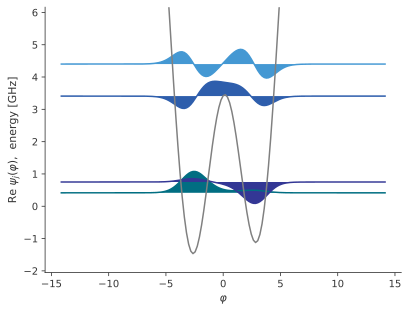

In [23]:
fluxonium2 =  scqubits.Fluxonium(EJ=3.45,
                        EC=4/7,
                        EL=4/8,
                        flux=0.48,cutoff=110,
                        truncated_dim=12)
fluxonium2.plot_wavefunction(which=[0,1,2,3])


(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

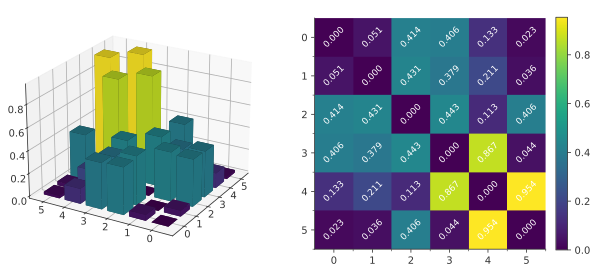

In [24]:
fluxonium2.plot_matrixelements('n_operator',show_numbers=True)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

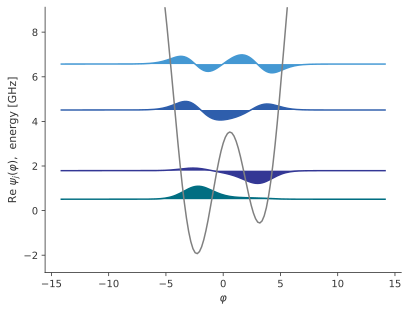

In [2]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium1 = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=12)

fluxonium2 =  scqubits.Fluxonium(EJ=3.45,
                        EC=4/4,
                        EL=4/8,
                        flux=0.42,cutoff=110,
                        truncated_dim=12)


system = FluxoniumFluxoniumSystem(
    fluxonium1  = fluxonium1,
    fluxonium2 = fluxonium2,
    computaional_states = '1,2',
    g_strength = 0.3,
    )

fluxonium2.plot_wavefunction(which=[0,1,2,3])


# Control

In [3]:
system.evals[system.product_to_dressed[(0,3)]]-system.evals[system.product_to_dressed[(0,2)]], \
system.evals[system.product_to_dressed[(1,3)]]-system.evals[system.product_to_dressed[(1,2)]], \
system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]]

(2.01809366419117, 2.0735678014074175, 2.0404323045943613)

# First Leg

In [4]:
system.evals[system.product_to_dressed[(0,2)]]-system.evals[system.product_to_dressed[(0,0)]], \
system.evals[system.product_to_dressed[(1,2)]]-system.evals[system.product_to_dressed[(1,0)]], \
system.evals[system.product_to_dressed[(2,2)]]-system.evals[system.product_to_dressed[(2,0)]]

(4.040549932611718, 3.999053542158466, 4.015330418251702)

# Second Leg of Raman

In [5]:
system.evals[system.product_to_dressed[(0,2)]]-system.evals[system.product_to_dressed[(0,1)]], \
system.evals[system.product_to_dressed[(1,2)]]-system.evals[system.product_to_dressed[(1,1)]], \
system.evals[system.product_to_dressed[(2,2)]]-system.evals[system.product_to_dressed[(2,1)]]

(2.760305282395656, 2.7190365474814087, 2.7353482254843478)

# Let's try EIT

In [6]:
initial_states = [
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)]),
    qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)])
]

e_ops = []
for ql in range(3):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))

# Get the Raman pi pulse parameters
op = system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)



length = 200


aera_probe = np.pi  * 0.3
amplitude_g02 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,0)]])   )
amplitude_g21 = aera_probe/( length * abs(op[system.product_to_dressed[(0,2)],  system.product_to_dressed[(0,1)]])   )

amplitude_e02 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,0)]])   )
amplitude_e21 = aera_probe/( length * abs(op[system.product_to_dressed[(1,2)],  system.product_to_dressed[(1,1)]])   )

amplitude_f02 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,0)]])   )
amplitude_f21 = aera_probe/( length * abs(op[system.product_to_dressed[(2,2)],  system.product_to_dressed[(2,1)]])   )

amplitude_g02, amplitude_g21,     amplitude_e02, amplitude_e21,     amplitude_f02, amplitude_f21

(0.014172681676791034,
 0.015032633642559124,
 0.011901243250416638,
 0.012977270302926685,
 0.012380036216113525,
 0.013414421467388974)

# This is a Raman drive without EIT (can be updated to STIRAP)

 Total run time:  12.71s*] Elapsed 12.71s / Remaining 00:00:00:00[*********57%*          ] Elapsed 3.44s / Remaining 00:00:00:02
 Total run time:  12.75s*] Elapsed 12.75s / Remaining 00:00:00:00
 Total run time:  12.78s*] Elapsed 12.78s / Remaining 00:00:00:00


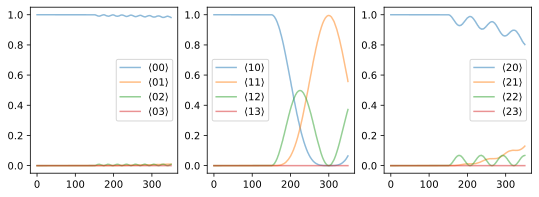

In [7]:
length = 350
tlist = np.linspace(0,length,int(length))
Delta = 0
results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # Raman first arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,0)]] +Delta/(2*np.pi),
                    'amp1':amplitude_e02,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 150
                  },
                ),

            # Raman second arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,1)]] + Delta/(2*np.pi),
                    'amp2': amplitude_e21,
                    't_rise2': 1e-5,
                    't_square2': 1000,
                    't_start2': 150
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

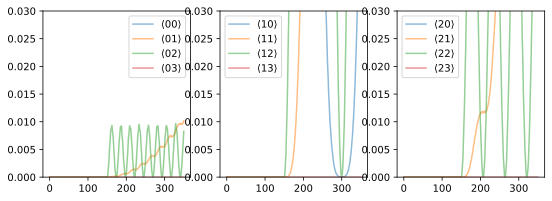

In [8]:
fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(0,0.03)


# Can I darken two transitions?

 Total run time:  32.51s*] Elapsed 32.51s / Remaining 00:00:00:00
 Total run time:  33.21s*] Elapsed 33.21s / Remaining 00:00:00:00
 Total run time:  33.67s*] Elapsed 33.67s / Remaining 00:00:00:00


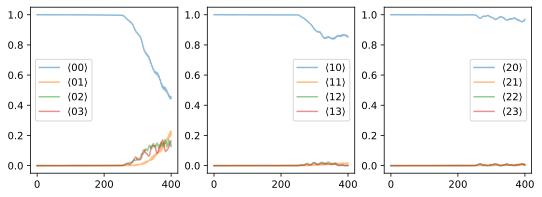

In [17]:
length = 400
tlist = np.linspace(0,length,int(length))
Delta = 0

results = system.run_qutip_mesolve_parrallel(
        initial_states = initial_states,
        tlist = tlist,
        drive_terms = [
            # EIT drive 1 
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d': 2.01809366419117,
                    'amp': 0.2,
                    't_rise':  200,
                    't_square': 1000,
                    't_start': 0
                  },
                ),

            # # EIT drive 2
            # DriveTerm( 
            #     driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
            #     pulse_shape_func=forth_square_pulse_with_rise_fall,
            #     pulse_shape_args={
            #         'w_d3':system.evals[system.product_to_dressed[(2,3)]]-system.evals[system.product_to_dressed[(2,2)]] - Delta/(2*np.pi),
            #         'amp3': 0.05,
            #         't_rise3':  100,
            #         't_square3': 1000,
            #         't_start3': 0
            #       },
            #     ),

            # Raman first arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=second_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d1':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,0)]] +Delta/(2*np.pi),
                    'amp1':amplitude_e02,
                    't_rise1': 1e-5,
                    't_square1': 1000,
                    't_start1': 250
                  },
                ),

            # Raman second arm
            DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.fluxonium2.n_operator)),
                pulse_shape_func=third_square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d2':system.evals[system.product_to_dressed[(1,2)]] - system.evals[system.product_to_dressed[(1,1)]] + Delta/(2*np.pi),
                    'amp2': amplitude_e21,
                    't_rise2': 1e-5,
                    't_square2': 1000,
                    't_start2': 250
                  },
                )
            ],
        c_ops = None,
        e_ops = e_ops,
        post_processing = []
    )

fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()

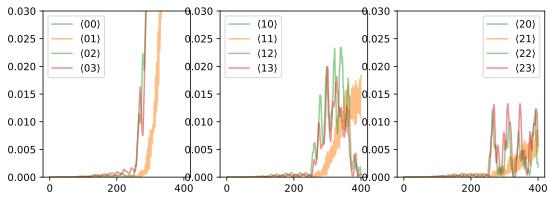

In [18]:
fig, axes = plt.subplots(1,3,figsize = (9,3))
for i, levels_list in enumerate( [[(0,0),(0,1),(0,2),(0,3)],
                                    [(1,0),(1,1),(1,2),(1,3)],
                                    [(2,0),(2,1),(2,2),(2,3)]] ):
    for (ql,tl) in levels_list:
        exp_idx = ql*4+tl
        axes[i].plot(tlist,results[i].expect[exp_idx],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[i].legend()
    axes[i].set_ylim(0,0.03)
